# Analysis of single experiment

## 1. Define path

In [11]:
# # GREEN
# dPaths = ["/media/DATA/MAK/GRISZ_02/AA0001",
#           "/media/DATA/MAK/GRISZ_03/AA0001",
#           "/media/DATA/MAK/GRISZ_05/AA0001",
# ]
# EXAMPLE DATA (format = 'PAC')
# dPaths = ["../data/AA0308","../data/AA0315"]
# dPaths = ["/media/DATA/MAK/TL_B10_Mouse04/AA0001"]
dPaths = ["/media/DATA/MAK/GRISZ_02/AA0001"]

## 2. Initialize experiment object

In [12]:
import lib.experiment_oop as exp
import importlib
importlib.reload(exp)

# define baseline and response windows
t_base = (2.0, 3.0)
t_resp = (3.3, 4.0)

# subfolder (bool): Whether to search recursively within subfolders for qcam files.
e0 = exp.Experiment(dPaths[0], subfolder=True, t_base = t_base, t_resp = t_resp)
e0

,qcam,dir,xsg,pulse,dB,treatment
1,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0017...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0017...,6-64kHz_40dB_10000msTotal_Fs250kHz,40,CTRL
2,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0032...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0032...,6-64kHz_70dB_10000msTotal_Fs250kHz,70,CTRL
3,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0033...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0033...,6-64kHz_30dB_10000msTotal_Fs250kHz,30,CTRL
4,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0034...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0034...,6-64kHz_40dB_10000msTotal_Fs250kHz,40,CTRL
5,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0035...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0035...,6-64kHz_50dB_10000msTotal_Fs250kHz,50,CTRL
...,...,...,...,...,...,...
89,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0018...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0018...,6-64kHz_50dB_10000msTotal_Fs250kHz,50,CTRL
90,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0019...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0019...,6-64kHz_70dB_10000msTotal_Fs250kHz,70,CTRL
91,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0020...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0020...,6-64kHz_60dB_10000msTotal_Fs250kHz,60,CTRL
92,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0021...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0021...,6-64kHz_80dB_10000msTotal_Fs250kHz,80,CTRL


In [13]:
# view trace count by treatment
e0.df['treatment'].value_counts()

treatment
CTRL    92
Name: count, dtype: int64

## 3. Load qcam data

In [14]:
#         exclude_non_loop_trials (bool, optional): Whether to remove trials collected outside of collection loop.
#         loop_gap_s (float, optional): Time gap (in seconds) between adjacent trials within the collection loop.
#                                    If `exclude_non_loop_trials` is `True`, first few trials with gaps above this threshold will be removed.

e0.load_qcam_data(exclude_non_loop_trials = True, loop_gap_s = 30)
e0

,qcam,dir,xsg,pulse,dB,treatment,nFrames,timestamp_init,dim_YX
0,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0017...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0017...,6-64kHz_40dB_10000msTotal_Fs250kHz,40,CTRL,200,2024-11-18 14:28:55,"(130, 174)"
1,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0018...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0018...,6-64kHz_50dB_10000msTotal_Fs250kHz,50,CTRL,200,2024-11-18 14:29:16,"(130, 174)"
2,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0019...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0019...,6-64kHz_70dB_10000msTotal_Fs250kHz,70,CTRL,200,2024-11-18 14:29:36,"(130, 174)"
3,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0020...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0020...,6-64kHz_60dB_10000msTotal_Fs250kHz,60,CTRL,200,2024-11-18 14:29:56,"(130, 174)"
4,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0021...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0021...,6-64kHz_80dB_10000msTotal_Fs250kHz,80,CTRL,200,2024-11-18 14:30:16,"(130, 174)"
...,...,...,...,...,...,...,...,...,...
87,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0104...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0104...,6-64kHz_80dB_10000msTotal_Fs250kHz,80,CTRL,200,2024-11-18 14:57:56,"(130, 174)"
88,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0105...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0105...,6-64kHz_60dB_10000msTotal_Fs250kHz,60,CTRL,200,2024-11-18 14:58:16,"(130, 174)"
89,/media/DATA/MAK/GRISZ_02/AA0001/AA0001Asdx0018...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001Asdx0018...,6-64kHz_80dB_10000msTotal_Fs250kHz,80,CTRL,200,2024-11-18 16:26:57,"(130, 174)"
90,/media/DATA/MAK/GRISZ_02/AA0001/AA0001Asdx0019...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001Asdx0019...,6-64kHz_50dB_10000msTotal_Fs250kHz,50,CTRL,200,2024-11-18 16:28:00,"(130, 174)"


## 4. Overview plots (without ROI)

In [15]:
# rough first view of average across all traces
e0.plot_average_fluorescence()

/home/pac/Documents/Python/pyFluo/src/lib/experiment_oop.py:159: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



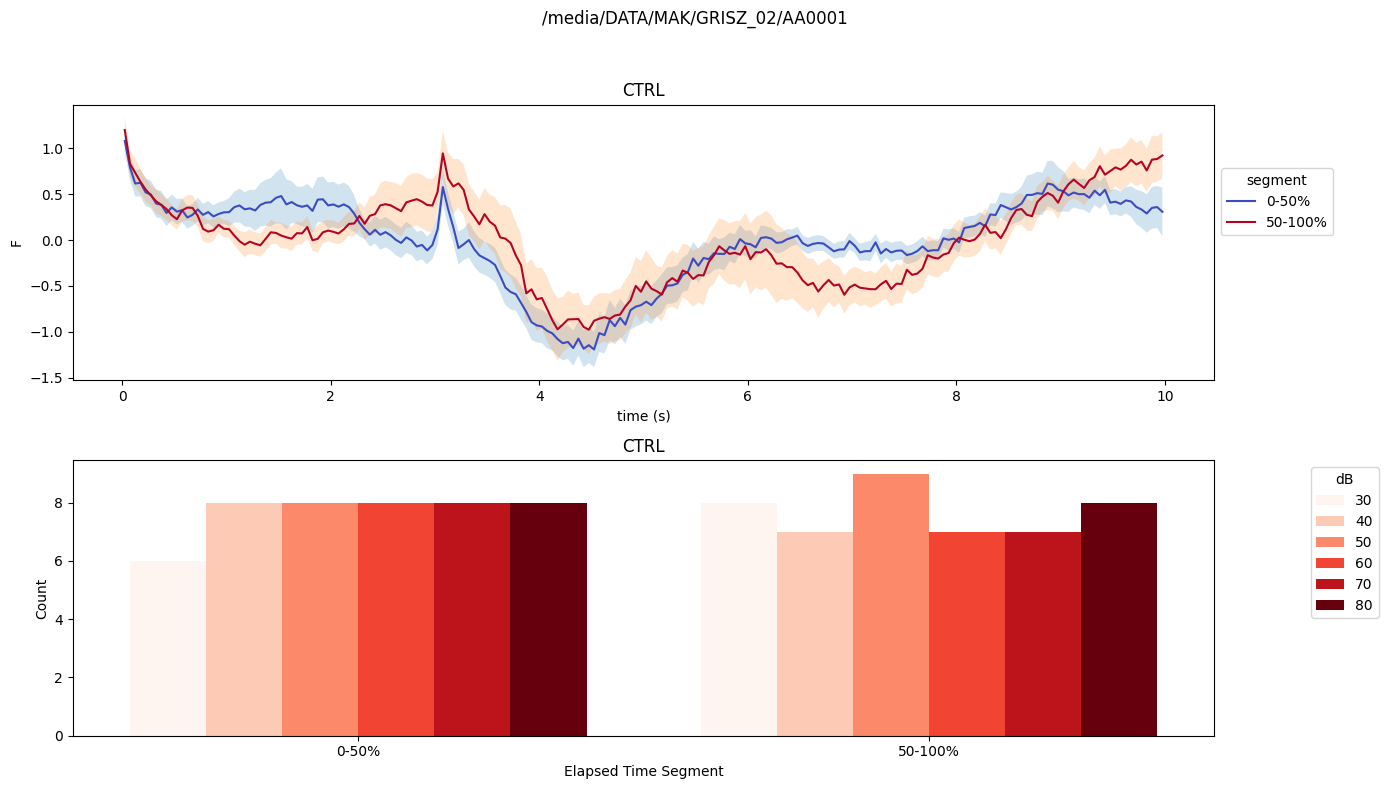

In [16]:
n_segments = 2
e0.plot_experiment_segments(n_segments)

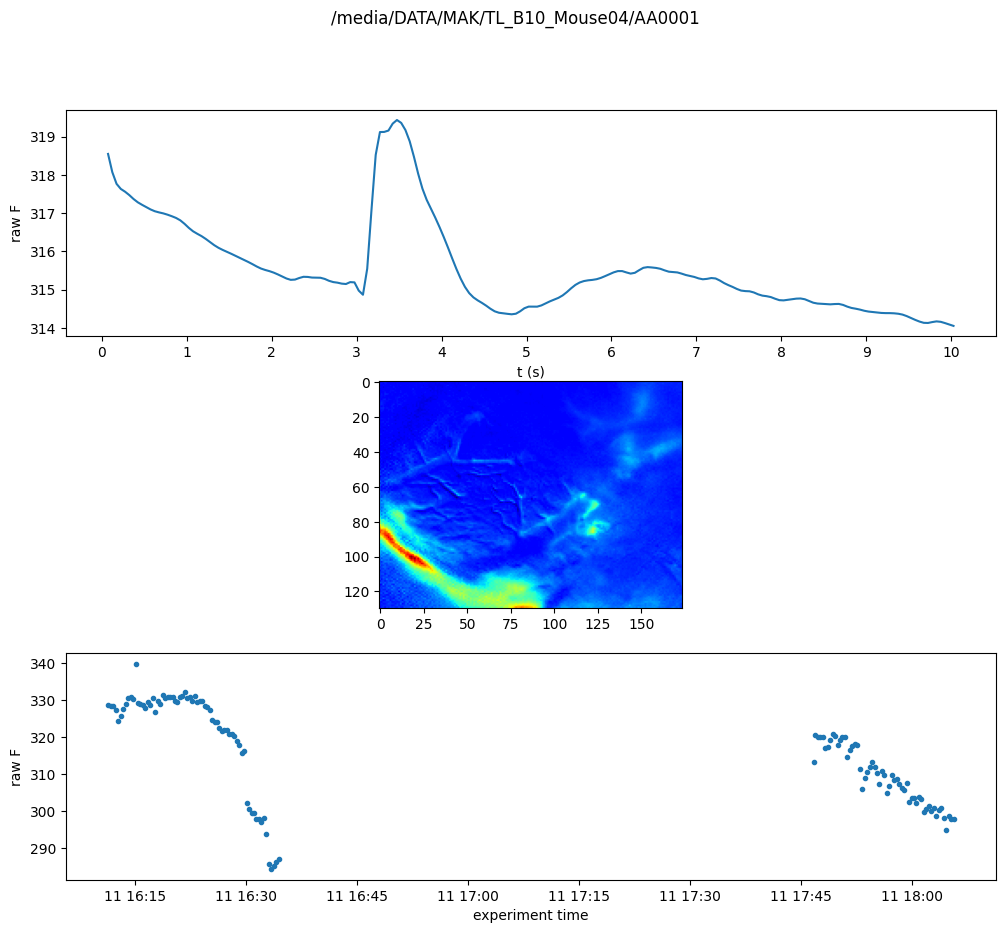

In [14]:
e0.plot_experiment_overview()

In [13]:
# without ROI selection
e0.plotDF_levelByTreatment()

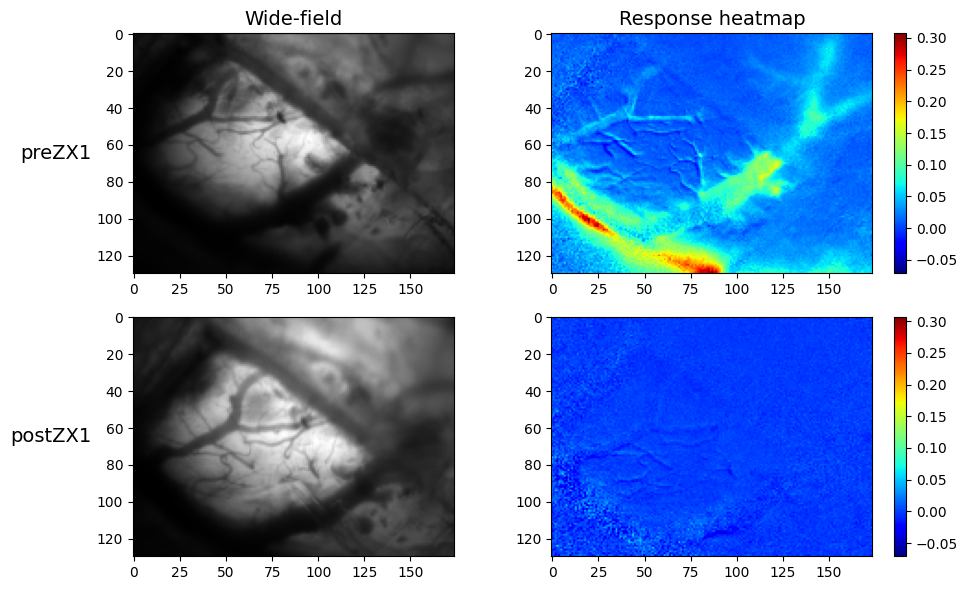

In [14]:
# view spatial dFF re condition
# specify sound intensity, baseline and response time window
dB_plot = 80

e0.plot_respHeatmap(dB_plot=dB_plot)

## 5. Draw ROI and save to experiment directory (via button)

In [9]:
# SAME ROI regardless of treatment
ui, mask_output, imgSeries, spatialDFF = e0.get_ROI_mask()

# Separate ROI by treatment
# ui, mask_output, imgSeries, spatialDFF = e0.get_ROI_mask(condition='pre')
# ui, mask_output, imgSeries, spatialDFF = e0.get_ROI_mask(condition='post')

# Load existing ROI
# import lib.imgProcess as imgProcess
# defined_mask = imgProcess.getSquareMask(5, 85, 40, 10, angle=90, rotate=30)
# ui, mask_output, imgSeries, spatialDFF = e0.get_ROI_mask(condition='post', existing_roi = defined_mask['ROIcontour'])

In [10]:
ui

BokehModel(combine_events=True, render_bundle={'docs_json': {'88c1d49e-1fcc-499a-8bd9-5ed8024080e3': {'version…

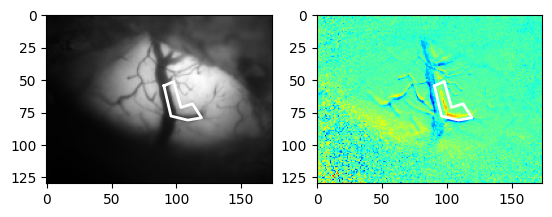

In [11]:
e0.plot_ROI_mask(mask_output, imgSeries, spatialDFF)

## 6. Process qcam files re saved ROI and apply criteria + filtering

In [12]:
e0.process_signal()
e0

,qcam,dir,xsg,pulse,dB,treatment,nFrames,timestamp_init,dim_YX,ROImask,...,f0_ROI_linFilt_butterFilt,dF_ROI_raw,dF_ROI_raw_peak,dF_ROI_linFilt_butterFilt,dF_ROI_linFilt_butterFilt_peak,dFF_ROI_raw,dFF_ROI_raw_peak,dFF_ROI_linFilt_butterFilt,dFF_ROI_linFilt_butterFilt_peak,valid
0,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0017...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0017...,6-64kHz_40dB_10000msTotal_Fs250kHz,40,CTRL,200,2024-11-18 14:28:55,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,459.187544,"[2.2668044077134937, -1.105096418732785, 0.674...",3.476171,"[1.4804683218374635, -0.030211134997045974, -1...",1.991193,"[0.004949677625814947, -0.0024130317549926174,...",0.007590,"[0.003224103837763708, -6.579258390769343e-05,...",0.004336,True
1,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0018...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0018...,6-64kHz_50dB_10000msTotal_Fs250kHz,50,CTRL,200,2024-11-18 14:29:16,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,443.647553,"[7.427134986225894, 4.710881542699724, 2.23705...",0.573140,"[3.788966510840794, 2.0716062154733663, 0.6155...",0.133644,"[0.016777127524028775, 0.010641392749565255, 0...",0.001295,"[0.008540487795997575, 0.004669486402358551, 0...",0.000301,True
2,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0019...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0019...,6-64kHz_70dB_10000msTotal_Fs250kHz,70,CTRL,200,2024-11-18 14:29:36,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,434.792278,"[1.0889807162534453, 4.948484848484895, 4.9154...",4.199174,"[-2.8777033850514044, -2.2095411137643737, -1....",2.901795,"[0.0025058049351615883, 0.01138673768032076, 0...",0.009663,"[-0.006618570587939228, -0.0050818315412108185...",0.006674,True
3,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0020...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0020...,6-64kHz_60dB_10000msTotal_Fs250kHz,60,CTRL,200,2024-11-18 14:29:56,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,431.124611,"[3.5216253443526284, -1.5885674931129756, 3.76...",3.576722,"[1.1186987019086132, 0.454203032721864, -0.113...",3.481242,"[0.008174082018330406, -0.003687240893237608, ...",0.008302,"[0.0025948384162760327, 0.0010535307461115222,...",0.008075,True
4,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0021...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0021...,6-64kHz_80dB_10000msTotal_Fs250kHz,80,CTRL,200,2024-11-18 14:30:16,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,428.512981,"[5.130716253443552, 4.488842975206637, 0.08939...",6.904821,"[2.6902519802135316, 2.0212265812836563, 1.458...",3.885499,"[0.011949923823205736, 0.010454940199051035, 0...",0.016082,"[0.006278110817603856, 0.004716838630029811, 0...",0.009067,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0104...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0104...,6-64kHz_80dB_10000msTotal_Fs250kHz,80,CTRL,200,2024-11-18 14:57:56,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,418.054175,"[5.612258953168009, 4.529614325068849, 3.85192...",1.157713,"[1.8596162269311662, 0.5965647655876296, -0.52...",0.683644,"[0.013449791461387675, 0.01085523112548127, 0....",0.002774,"[0.00444826612768183, 0.001427003486687756, -0...",0.001635,True
88,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0105...,/media/DATA/MAK/GRISZ_02/AA0001,/media/DATA/MAK/GRISZ_02/AA0001/AA0001AAAA0105...,6-64kHz_60dB_10000msTotal_Fs250kHz,60,CTRL,200,2024-11-18 14:58:16,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,412.461748,"[-0.5417355371901635, 3.287465564738227, 2.571...",4.405923,"[-1.5720936863027646, -0.20338040212328679, 0....",1.338711,"[-0.0013109069256084774, 0.007955101854434843,.

## 7. Plot processed data re ROI

In [15]:
# TODO: plotDF_levelByTreatment with df + response col instead of qcam2img (can add logic to existing function)
e0.plotDF_levelByTreatment(roi_mask=mask_output['mask'])

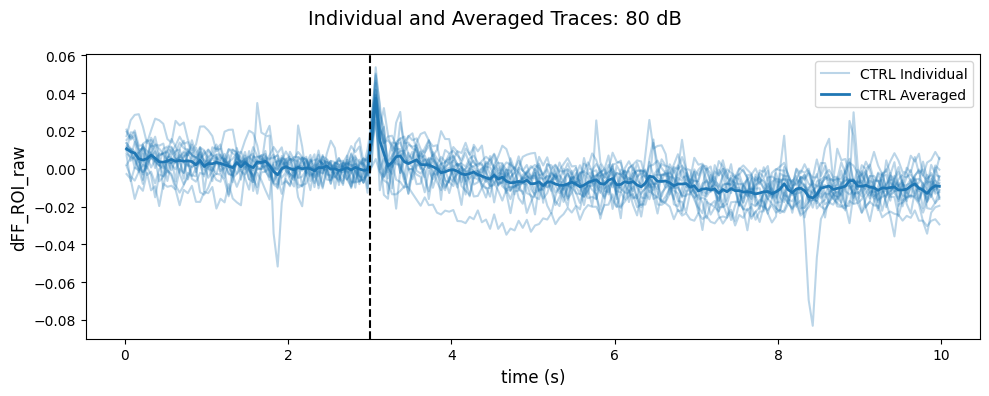

In [13]:
# TODO: add this to experiment_oop.py
import lib.plotting as plotting
plotting.plot_traces(e0.df, dB_plot=80, resp_col='dFF_ROI_raw', sepPlot=False)

In [14]:
# TODO: add this to experiment_oop.py
import plotly.express as px

fig = px.violin(e0.df, y="dFF_ROI_linFilt_butterFilt_peak", x="dB", color="treatment", box=True, points='all')
fig.show()
